## Offline evals : 
the evals examples that we have discussed till now are offline evals only . 
any eval pipeline which is used before deploying it is offline eval . 
ye software ke banne ke baad , but deployment ke pehle hora hai 

so app agar ek application ko deploy krne ke pehle test karna chahte ho - toh wo offline evals hota hai . 

### Main Purpose of Offline Evals : 
1. if we deploy without testing it , we will not be sure how the application will perform in production . 
so offline eval gives us PRE-RELEASE TESTING (GATING)
we can even create gates like CI/CD to automate the offline evals . 


2. Version Comparison : we can use same eval for differenct version or different componenets like we can compare diffrenet prompt , different retrievers ,etc using the smae evals . 


3. Regression testing : 
sommetimes when we do somehting to imrpove one thing , but it leads to make other thing perform poorly : this is called as regression . 
and to test this is called regression testing . 

whenever we were improving software , we have to make sure that this doesn't lead to making other bad 



### But What about Post-deployment .
these risks are not solved using offline evals .  

1. Unanticiapted input :
questions mixing hindi and eng , ambigious half- questions , angry rant with a read question buried inside , adversarial prompt - injection attempts , questions about edge-case scenerious you never considered .

2. Emergent / systemic failures : 
problems that only exists at scale , under load , over time ( a retrieval index silently lagging its source document, cost per conversation quietly tripling after a prompt change , the latency tail (p99) , frustrating a slice of users ,a subtle bias that only becomes visible across thousands of conversations , degradation that only appears under real concurrent loads ) .

3. Drift : evantually the offline eval become obsolite (no longer functional ) .



## Online Evals : 
online eval is evaluating you system on live production traffic , after deployment , as real users interact with it . 

it works with any golden dataset . 


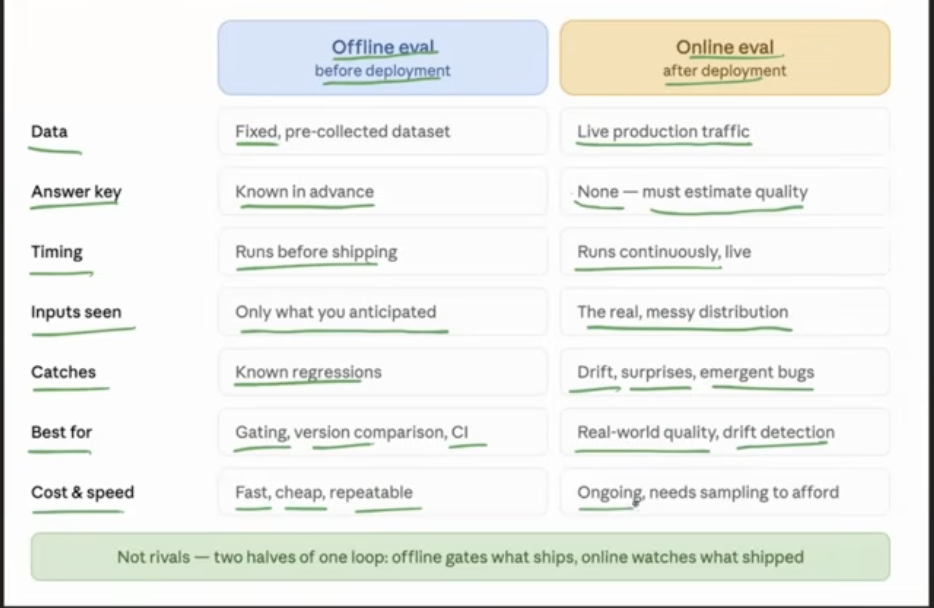

Offline eval -> ye check krta hai ki appka application sahi se kaam kr rha hai ? 
online eval -> appka application normally kaam kr rha hai ? 

so , how do we know ki normally kaam kr rhe hai . 
by comparing the distribution of scores of today with the distribution of past , if it same or similar than the system is working normally . 


### Online Evals Pipeline :

1. Logging : Whatever you want to evals , you must record it somewhere . 
Capture a structured,  replayable record of every conversation turn . 

Identify/threading : conversation_id, turn_id , user_id/session_id , timestamp 

Input : raw message , plus any preprocessing (normallized text , detected language / intent )

Retrieved context

Output : response text , model_name , prompt_version (needed for A/B testing and "which version regressed") , tool_calls  finiish reason 

Operation telemetry : This is the operational metric family : latency_ms (ideally split into retrieval vs generation) 
prompt_tokens , completion_tokens , derived cost , error /status codes . 

Downstread user signals : this is the behavioral - metric family 
thumbs up/down , escalation to suppport , dropoff , rephrase , conversion . 


### Engineering properties : 
- Non-Blocking - logging must never add latency to the response .fire tot a queue 

- Durable + queryable - a warehouse or observability tool you can run analytical queries againse , not scattered text logs . 

- Late - signal attachment - signals alnd at different times (thumbs - down in secons , escalation in an hour , conversion the next day , so records are keyed on conversation_id and updated as signals arrives ).

- PII handline (personal identifiable information )- scrub / tokenize emails , phone numbers , payment details , apply retentin liimits and access co;ntrol 




in logging - when log two things : 
--  Computed 
-- Captured 
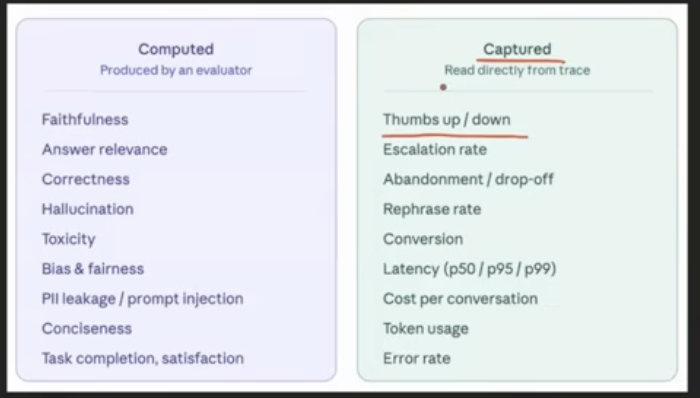

if captured quantity : 
you log -> you present on dashboard -> you put some alert . 
the captured quantities always mattered in aggregated time period like last 1 hour , last 1 week , last 1 months.


now to tack computed : 
let's say i want to check if my system hallucinates or not ? 
pipeline : 
logging -> set up a evaluator (this evaluator is a reference free .)